['t', 'press']
<class 'numpy.ndarray'>
(13731,)
[1.74730692e+09 1.74730692e+09 1.74730692e+09 1.74730692e+09
 1.74730692e+09]
wav shape: (1641875, 2, 5)


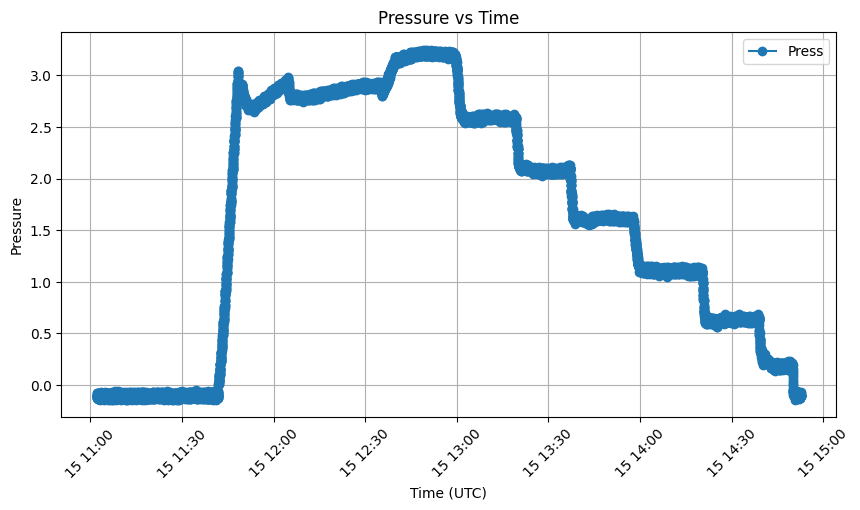

In [17]:
import uproot
import matplotlib.pyplot as plt
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT con uproot
with uproot.open(input_filename) as file:
    tree = file["press"]  # árbol correcto
    print(tree.keys())  # lista todas las columnas disponibles
    data = tree.arrays(library="np")  # Devuelve un diccionario de numpy arrays

# Extraer tiempos y valores 
times = data["t"]       # Asegúrate de que la columna exista en este árbol
press = data["press"]

print(type(times))
print(times.shape)
print(times[:5])

# === Cargar el espectro wav para análisis espectral ===
with uproot.open(input_filename) as file:
    peak_data = file["peak"].arrays(library="np")
wav = peak_data["wav"]  # shape: (n_eventos, n_pol, n_sensor)
print(f"wav shape: {wav.shape}")

# Convertir tiempos a formato datetime
timestamps = [datetime.datetime.utcfromtimestamp(float(t)) for t in times]

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(timestamps, press, marker='o', linestyle='-', label='Press')
plt.xlabel("Time (UTC)")
plt.ylabel("Pressure")
plt.title("Pressure vs Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


In [18]:
import uproot

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT
with uproot.open(input_filename) as file:
    print("Trees y ramas disponibles en el archivo ROOT:\n")
    
    for key in file.keys():  # recorrer todos los árboles
        # Quitar el ciclo (;n) para mostrar solo el nombre base
        tree_name = key.split(";")[0]
        print(f"Árbol: {tree_name}")
        
        tree = file[tree_name]  # abrir el árbol
        branches = tree.keys()  # obtener todas las columnas/ramas
        print(f"  Ramas: {branches}\n")


Trees y ramas disponibles en el archivo ROOT:

Árbol: peak
  Ramas: ['t', 'wav', 'sweep', 'ch', 'pos']

Árbol: press
  Ramas: ['t', 'press']

Árbol: spectrum
  Ramas: ['t', 'wav']

Árbol: temp


  Ramas: ['t', 'temp']



In [ ]:
import uproot
import numpy as np
import datetime

# --- Archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# --- Abrir el archivo ROOT ---
with uproot.open(input_filename) as file:
    peak_data = file["peak"].arrays(library="np")

wav = peak_data["wav"]  # shape: (n_time, n_pol, n_sensor)
n_times, n_pols, n_sensors = wav.shape

print("=== Wavelength array structure ===")
print(f"Shape: {wav.shape}  (time, polarization, sensor)")
print(f"Number of samples: {n_times:,}")
print(f"Number of polarizations: {n_pols} (0=P, 1=S)")
print(f"Number of sensors: {n_sensors}\n")

# --- Clasificación corregida según tu descripción ---
# Fiber ORMOCER FBGs-2 → 4 FBGs (0–3)
# Fiber PEEK-3 → 1 FBG (4)
fiber_map = {
    "ORMOCER FBGs-2": [0, 1, 2, 3],
    "PEEK-3": [4]
}

print("=== Approximate wavelength centers per fiber ===")
for fiber_name, sensors in fiber_map.items():
    print(f"\nFiber: {fiber_name}")
    for s in sensors:
        mean_P = np.mean(wav[:, 0, s]) * 1e3  # µm → nm
        mean_S = np.mean(wav[:, 1, s]) * 1e3
        diff_pm = (mean_S - mean_P) * 1e3  # nm → pm
        print(f"  Sensor {s}: λ_P = {mean_P:3e} nm | λ_S = {mean_S:3e} nm | Δ(P–S) = {diff_pm:3e} pm")

# --- Mostrar los primeros valores de cada sensor ---
#print("\n=== First 5 wavelength samples per sensor ===")
#for s in range(n_sensors):
    #print(f"\nSensor {s} (P): {wav[:5, 0, s] * 1e3}")
    #print(f"Sensor {s} (S): {wav[:5, 1, s] * 1e3}")


In [21]:
import uproot
import numpy as np
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    press_tree = file["press"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    press_data = press_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Tiempos de cada árbol ---
peak_times = peak_data["t"][:, 0]  # primera columna si hay varias
press_times = press_data["t"]      # normalmente 1D
temp_times = temp_data["t"]        # normalmente 1D

# --- Convertir a datetime ---
peak_start = datetime.datetime.utcfromtimestamp(peak_times[0])
press_start = datetime.datetime.utcfromtimestamp(press_times[0])
temp_start = datetime.datetime.utcfromtimestamp(temp_times[0])

print(f"Start time of Peak data: {peak_start}")
print(f"Start time of Pressure data: {press_start}")
print(f"Start time of Temperature data: {temp_start}")

# --- Primer pico de cada canal de Peak ---
n_channels_i = peak_data["wav"].shape[1]
n_channels_j = peak_data["wav"].shape[2]

for i in range(n_channels_i):
    for j in range(n_channels_j):
        wav_ = peak_data["wav"][:, i, j]
        first_idx = np.argmax(wav_ > 0)  # primer valor mayor que cero
        first_time = datetime.datetime.utcfromtimestamp(peak_times[first_idx])
        print(f"Channel [{i},{j}] first peak timestamp: {first_time}")


Start time of Peak data: 2025-05-15 09:13:37.651806
Start time of Pressure data: 2025-05-15 11:01:59
Start time of Temperature data: 2025-05-15 10:45:13
Channel [0,0] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [0,1] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [0,2] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [0,3] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [0,4] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [1,0] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [1,1] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [1,2] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [1,3] first peak timestamp: 2025-05-15 09:13:37.651806
Channel [1,4] first peak timestamp: 2025-05-15 09:13:37.651806


In [22]:
# --- Convertir a datetime (con corrección de desfase de 2 horas en peak) ---
time_shift = datetime.timedelta(hours=2)

peak_start = datetime.datetime.utcfromtimestamp(peak_times[0]) + time_shift
press_start = datetime.datetime.utcfromtimestamp(press_times[0])
temp_start = datetime.datetime.utcfromtimestamp(temp_times[0])

print(f"Start time of Peak data: {peak_start}")
print(f"Start time of Pressure data: {press_start}")
print(f"Start time of Temperature data: {temp_start}")

# --- Primer pico de cada canal de Peak ---
for i in range(n_channels_i):
    for j in range(n_channels_j):
        wav_ = peak_data["wav"][:, i, j]
        first_idx = np.argmax(wav_ > 0)  # primer valor mayor que cero
        first_time = datetime.datetime.utcfromtimestamp(peak_times[first_idx]) + time_shift
        print(f"Channel [{i},{j}] first peak timestamp: {first_time}")


Start time of Peak data: 2025-05-15 11:13:37.651806
Start time of Pressure data: 2025-05-15 11:01:59
Start time of Temperature data: 2025-05-15 10:45:13
Channel [0,0] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [0,1] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [0,2] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [0,3] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [0,4] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [1,0] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [1,1] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [1,2] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [1,3] first peak timestamp: 2025-05-15 11:13:37.651806
Channel [1,4] first peak timestamp: 2025-05-15 11:13:37.651806


Channel wav_04: 1641875 points plotted (min=1.537894e-06, max=1.539086e-06)


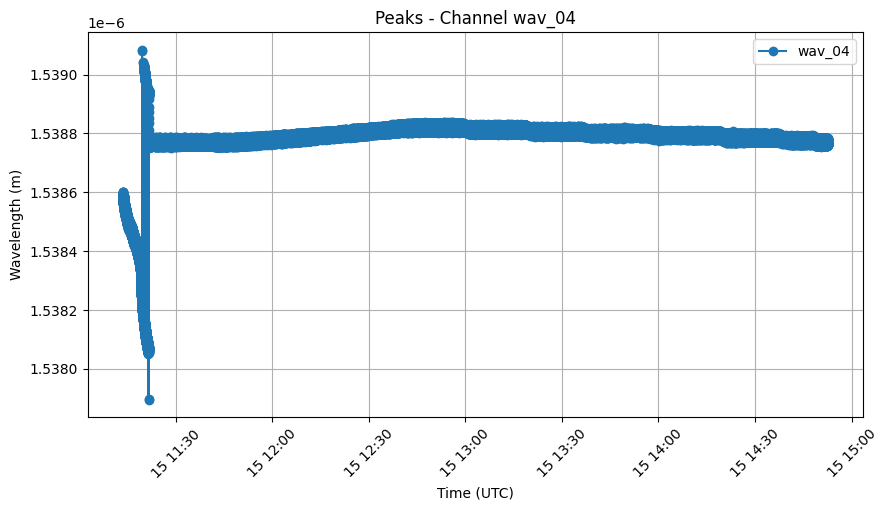

Channel wav_13: 1641875 points plotted (min=1.552415e-06, max=1.553442e-06)


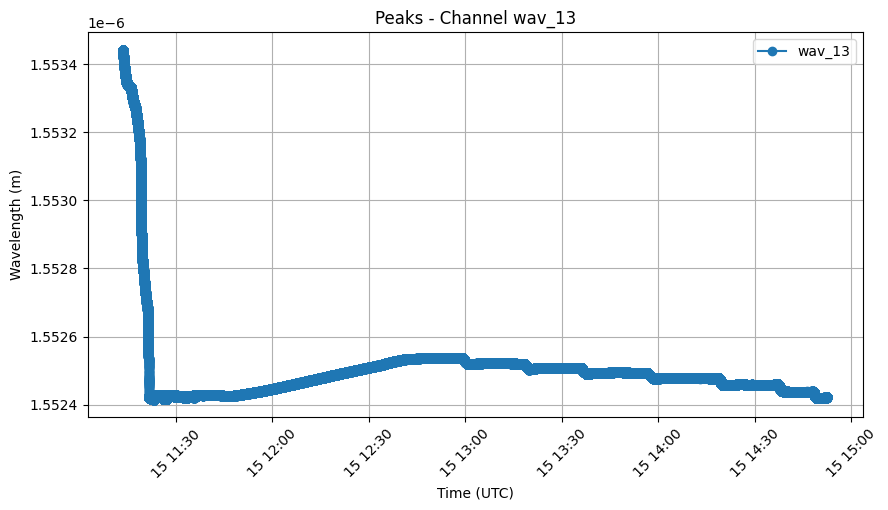

In [23]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT
with uproot.open(input_filename) as file:
    tree = file["peak"]
    data = tree.arrays(library="np")

# Extraer tiempos (primera columna si hay varias) y corregir desfase de 2 horas
times = data["t"][:, 0]
timestamps = np.array([datetime.datetime.utcfromtimestamp(t) + datetime.timedelta(hours=2) for t in times])

# Función para graficar un canal de wav automáticamente
def plot_wav_channel(i, j, label, umbral_min=None, umbral_max=None):
    wav_ = data["wav"][:, i, j]
    
    # Si no se pasan umbrales, usar 5% por debajo y por encima de los valores
    if umbral_min is None:
        umbral_min = np.min(wav_) - 0.05 * np.ptp(wav_)
    if umbral_max is None:
        umbral_max = np.max(wav_) + 0.05 * np.ptp(wav_)
    
    mask = (wav_ > umbral_min) & (wav_ < umbral_max)
    print(f"Channel {label}: {np.sum(mask)} points plotted (min={np.min(wav_):.6e}, max={np.max(wav_):.6e})")
    
    plt.figure(figsize=(10,5))
    plt.plot(timestamps[mask], wav_[mask], marker='o', linestyle='-', label=label)
    plt.xlabel("Time (UTC)")
    plt.ylabel("Wavelength (m)")
    plt.title(f"Peaks - Channel {label}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.show()

# Graficar los dos primeros canales
plot_wav_channel(0, 4, "wav_04")
plot_wav_channel(1, 3, "wav_13")


Channel wav_00 ormocer fbgs-2: 1069081 points plotted (min=1.537420e-06, max=1.538509e-06)


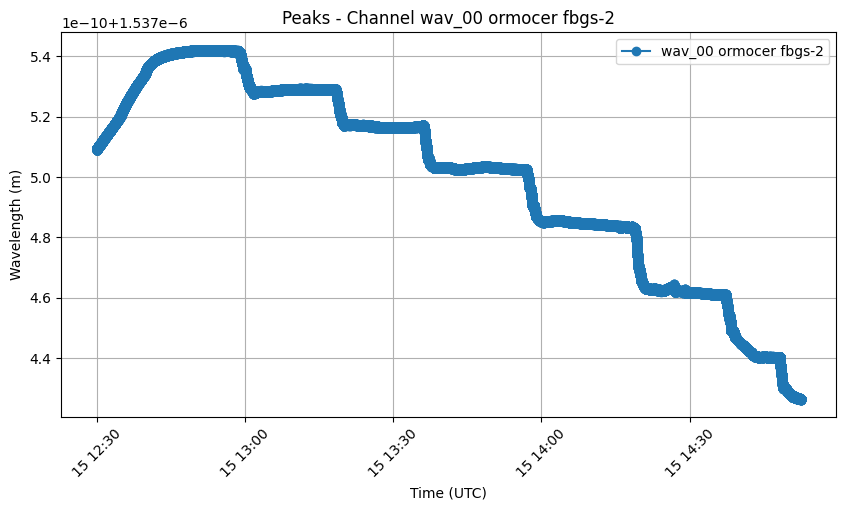

Channel wav_14 peek-3-alt: 1069081 points plotted (min=1.537892e-06, max=1.539116e-06)


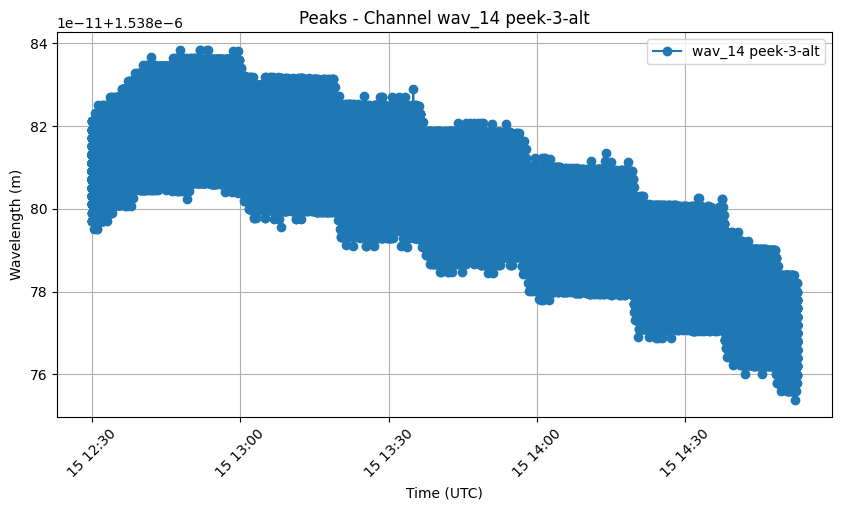

Channel wav_04 peek-3-alt: 1069081 points plotted (min=1.537894e-06, max=1.539086e-06)


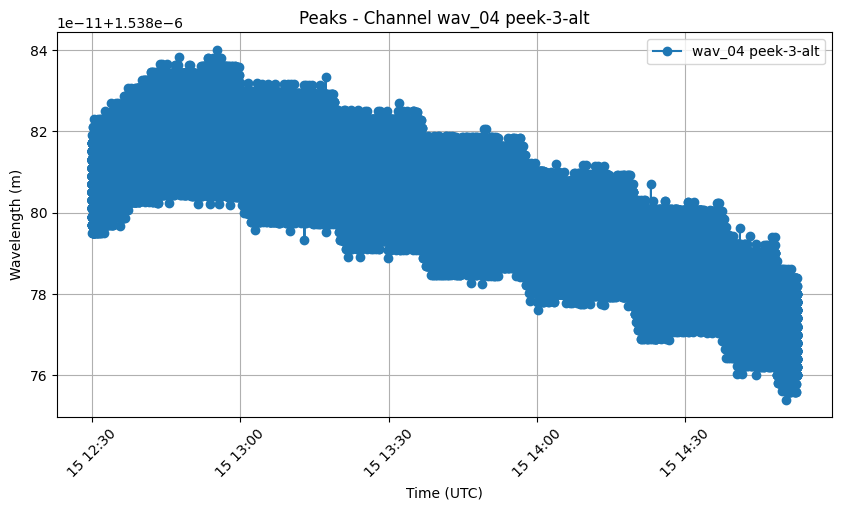

In [24]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT
with uproot.open(input_filename) as file:
    tree = file["peak"]
    data = tree.arrays(library="np")

# Extraer tiempos (primera columna si hay varias) y corregir desfase de 2 horas
times = data["t"][:, 0]
timestamps = np.array([datetime.datetime.utcfromtimestamp(t) + datetime.timedelta(hours=2) for t in times])

# Función para graficar un canal de wav automáticamente con filtrado por intervalo de tiempo
def plot_wav_channel(i, j, label, umbral_min=None, umbral_max=None, start_time=None, end_time=None):
    wav_ = data["wav"][:, i, j]
    
    # Si no se pasan umbrales, usar 5% por debajo y por encima de los valores
    if umbral_min is None:
        umbral_min = np.min(wav_) - 0.05 * np.ptp(wav_)
    if umbral_max is None:
        umbral_max = np.max(wav_) + 0.05 * np.ptp(wav_)
    
    # Filtrar por umbral
    mask = (wav_ > umbral_min) & (wav_ < umbral_max)
    
    # Filtrar por intervalo temporal
    if start_time is not None:
        mask &= (timestamps >= start_time)
    if end_time is not None:
        mask &= (timestamps <= end_time)
    
    print(f"Channel {label}: {np.sum(mask)} points plotted (min={np.min(wav_):.6e}, max={np.max(wav_):.6e})")
    
    plt.figure(figsize=(10,5))
    plt.plot(timestamps[mask], wav_[mask], marker='o', linestyle='-', label=label)
    plt.xlabel("Time (UTC)")
    plt.ylabel("Wavelength (m)")
    plt.title(f"Peaks - Channel {label}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.show()

# Definir hora de inicio del plot
start_time = datetime.datetime.strptime("2025-05-15 12:30:00", "%Y-%m-%d %H:%M:%S")

# Graficar los canales deseados
plot_wav_channel(0, 0, "wav_00 ormocer fbgs-2", start_time=start_time)
plot_wav_channel(1, 4, "wav_14 peek-3-alt", start_time=start_time)
plot_wav_channel(0, 4, "wav_04 peek-3-alt", start_time=start_time)


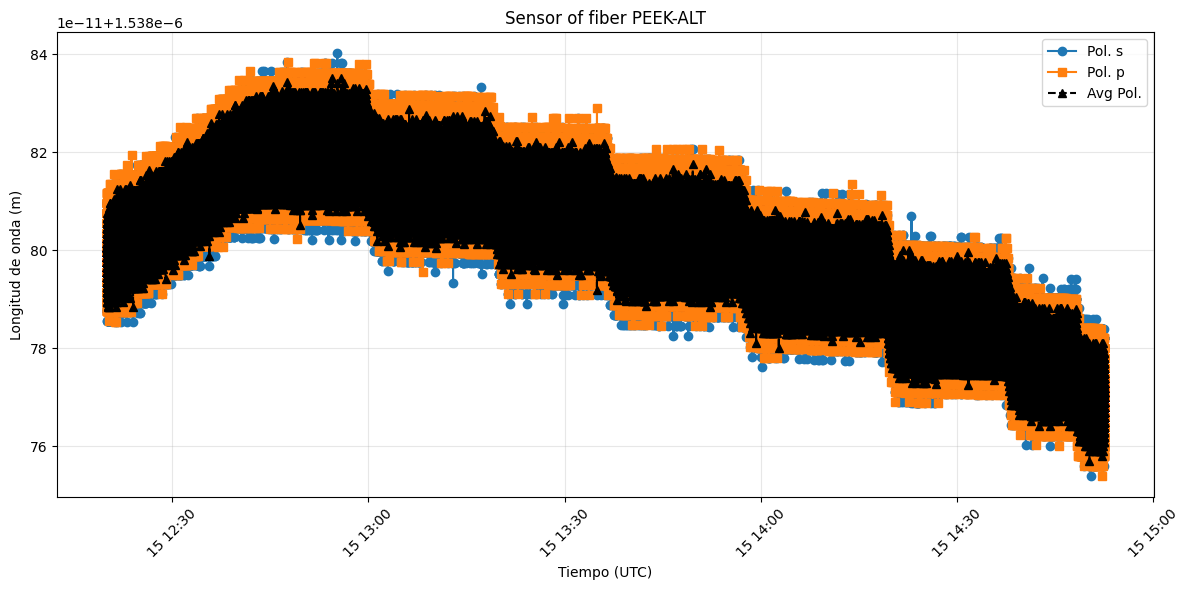

In [25]:
# -------------------------
# PLOT DE DOS POLARIZACIONES + MEDIA
# -------------------------
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT
with uproot.open(input_filename) as file:
    tree = file["peak"]
    data = tree.arrays(library="np")

# Extraer tiempos (primera columna si hay varias) y corregir desfase de 2 horas
times = data["t"][:, 0]
timestamps = np.array([datetime.datetime.utcfromtimestamp(t) + datetime.timedelta(hours=2) for t in times])

# Seleccionar los canales de interés
wav_04 = data["wav"][:, 0, 4]  # polarización 0
wav_14 = data["wav"][:, 1, 4]  # polarización 1

# Definir hora de inicio del plot
start_time = datetime.datetime.strptime("2025-05-15 12:20:00", "%Y-%m-%d %H:%M:%S")
mask_time = timestamps >= start_time

# Filtramos solo los puntos desde start_time
timestamps_plot = timestamps[mask_time]
wav_04_plot = wav_04[mask_time]
wav_14_plot = wav_14[mask_time]

# Calculamos la media de ambas polarizaciones
wav_mean_plot = (wav_04_plot + wav_14_plot) / 2

# -------------------------
# Plot combinado
# -------------------------
plt.figure(figsize=(12,6))

plt.plot(timestamps_plot, wav_04_plot, marker='o', linestyle='-', label='Pol. s')
plt.plot(timestamps_plot, wav_14_plot, marker='s', linestyle='-', label='Pol. p')
plt.plot(timestamps_plot, wav_mean_plot, marker='^', linestyle='--', color='black', label='Avg Pol.')

plt.xlabel("Tiempo (UTC)")
plt.ylabel("Longitud de onda (m)")
plt.title("Sensor of fiber PEEK-ALT")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Channel wav_01: 1144081 points plotted (min=0.000000e+00, max=1.543542e-06)


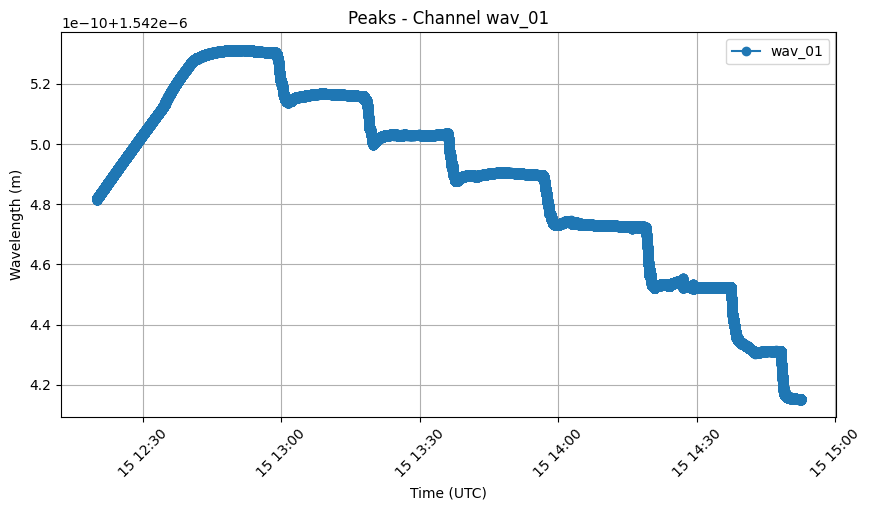

Channel wav_11: 1144081 points plotted (min=0.000000e+00, max=1.543552e-06)


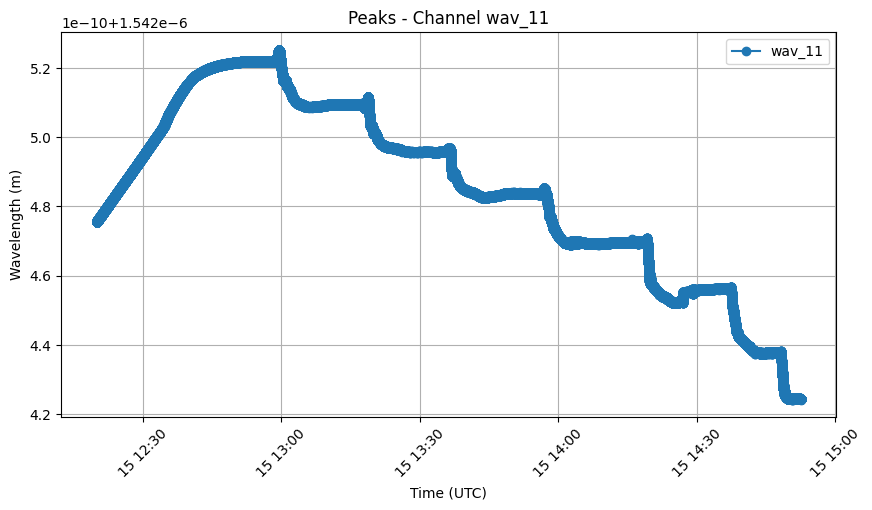

In [26]:
# Graficar wav[0][1]
plot_wav_channel(0, 1, "wav_01", start_time=start_time)

# Graficar wav[1][1]
plot_wav_channel(1, 1, "wav_11", start_time=start_time)


Channel wav_02: 1144081 points plotted (min=1.547438e-06, max=1.548662e-06)


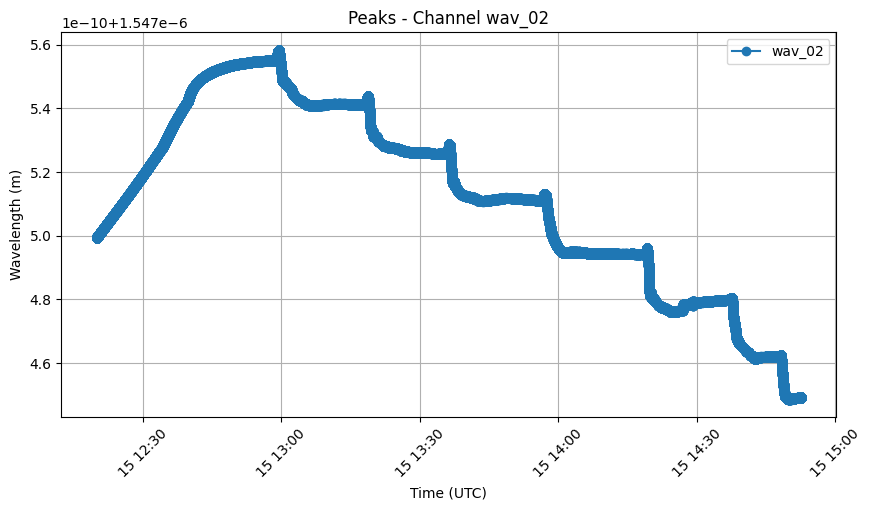

Channel wav_12: 1144081 points plotted (min=0.000000e+00, max=1.548655e-06)


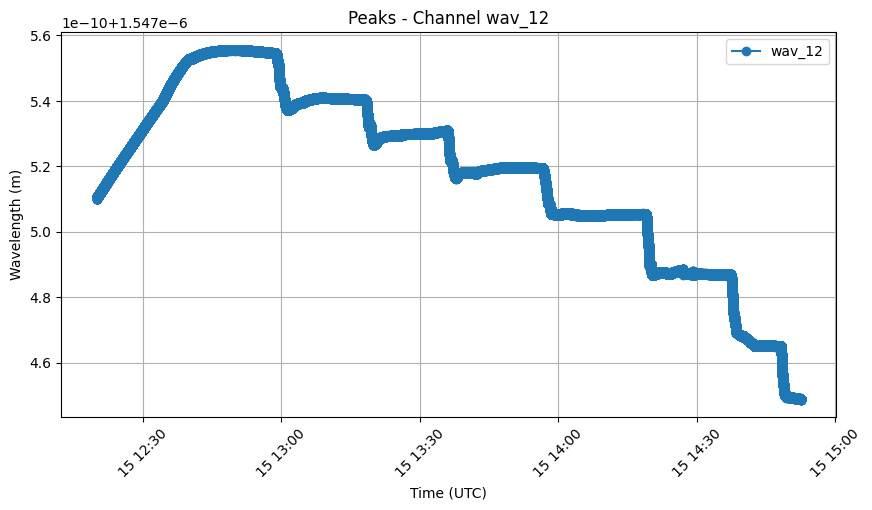

In [27]:
# Graficar wav[0][2] automáticamente ajustando el umbral
plot_wav_channel(0, 2, "wav_02", start_time=start_time)

# Graficar wav[1][2] automáticamente ajustando el umbral
plot_wav_channel(1, 2, "wav_12", start_time=start_time)

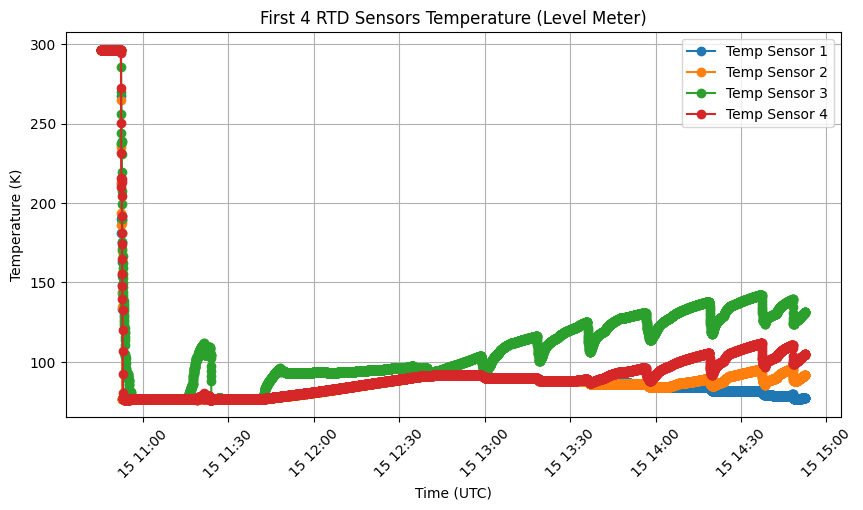

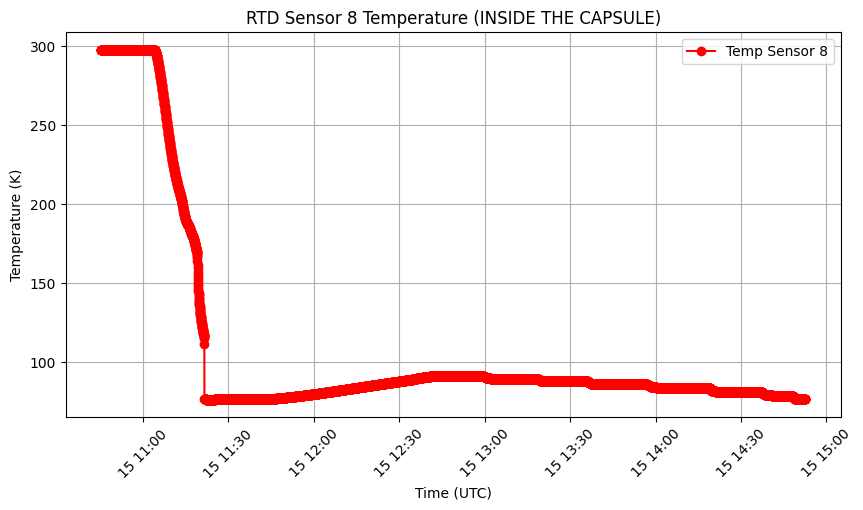

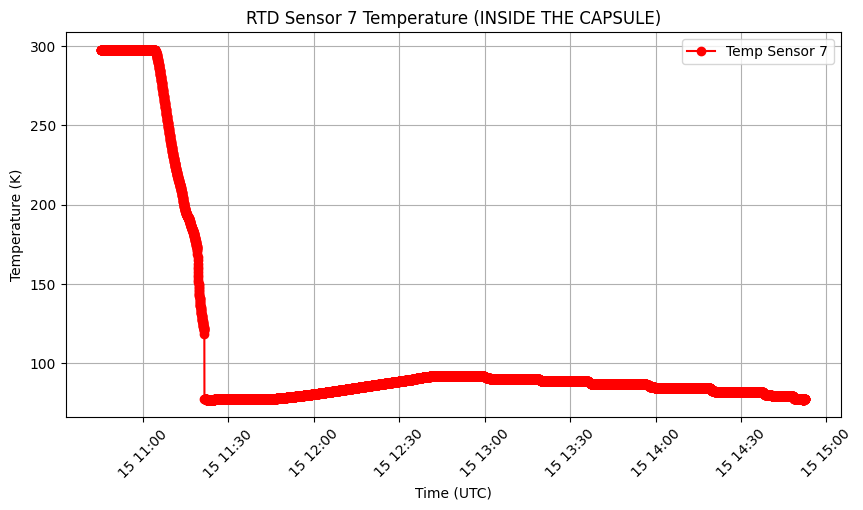

In [28]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"

# Abrir el archivo ROOT y cargar el árbol "temp"
with uproot.open(input_filename) as file:
    tree = file["temp"]
    data = tree.arrays(library="np")

# Extraer temperaturas
temp = data["temp"]

# Convertir tiempos a formato datetime
timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in data["t"]])  # ya es 1D

# 🔹 Graficar las temperaturas de los primeros 4 sensores (fuera de la cápsula)
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.plot(timestamps, temp[:, i], marker='o', linestyle='-', label=f'Temp Sensor {i+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title("First 4 RTD Sensors Temperature (Level Meter)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 🔹 Graficar un sensor específico (ej. último sensor)
sensor_id = 7  # índice del último sensor
plt.figure(figsize=(10, 5))
plt.plot(timestamps, temp[:, sensor_id], marker='o', linestyle='-', color='r', label=f'Temp Sensor {sensor_id+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title(f"RTD Sensor {sensor_id+1} Temperature (INSIDE THE CAPSULE)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 🔹 Graficar un sensor específico (ej. penúltimo sensor)
sensor_id = 6  # índice del penúltimo sensor
plt.figure(figsize=(10, 5))
plt.plot(timestamps, temp[:, sensor_id], marker='o', linestyle='-', color='r', label=f'Temp Sensor {sensor_id+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title(f"RTD Sensor {sensor_id+1} Temperature (INSIDE THE CAPSULE)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


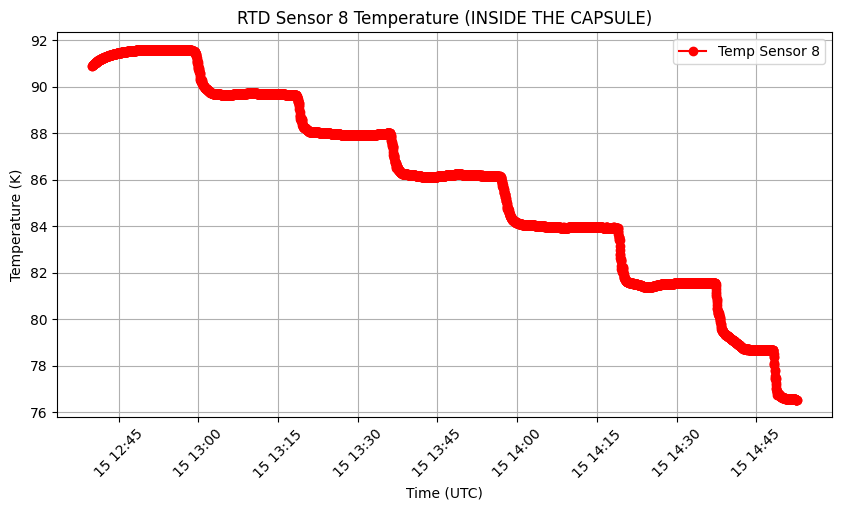

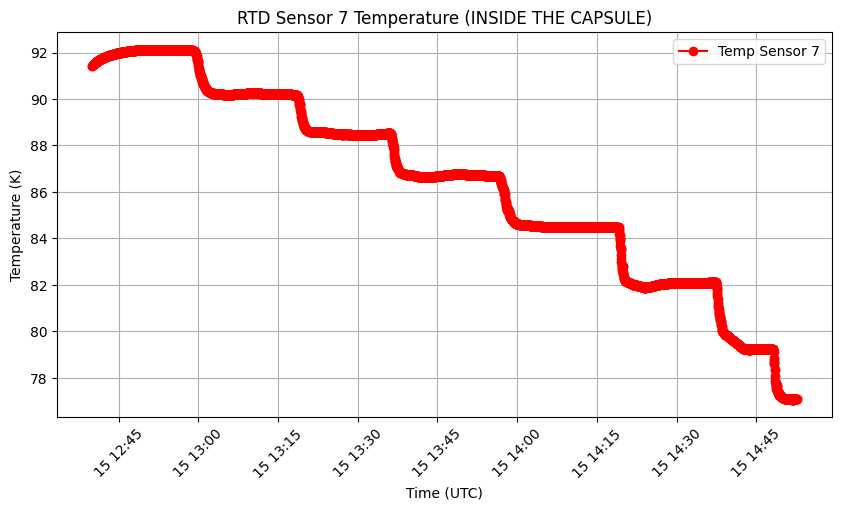

In [29]:
# --- Definir hora de inicio del plot ---
start_time = datetime.datetime.strptime("2025-05-15 12:40:00", "%Y-%m-%d %H:%M:%S")

# --- Crear máscara temporal ---
mask_time = timestamps >= start_time

# 🔹 Graficar el último sensor (ej. sensor 8, índice 7)
sensor_id = 7
plt.figure(figsize=(10, 5))
plt.plot(timestamps[mask_time], temp[:, sensor_id][mask_time],
         marker='o', linestyle='-', color='r', label=f'Temp Sensor {sensor_id+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title(f"RTD Sensor {sensor_id+1} Temperature (INSIDE THE CAPSULE)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 🔹 Graficar el penúltimo sensor (ej. sensor 7, índice 6)
sensor_id = 6
plt.figure(figsize=(10, 5))
plt.plot(timestamps[mask_time], temp[:, sensor_id][mask_time],
         marker='o', linestyle='-', color='r', label=f'Temp Sensor {sensor_id+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title(f"RTD Sensor {sensor_id+1} Temperature (INSIDE THE CAPSULE)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()


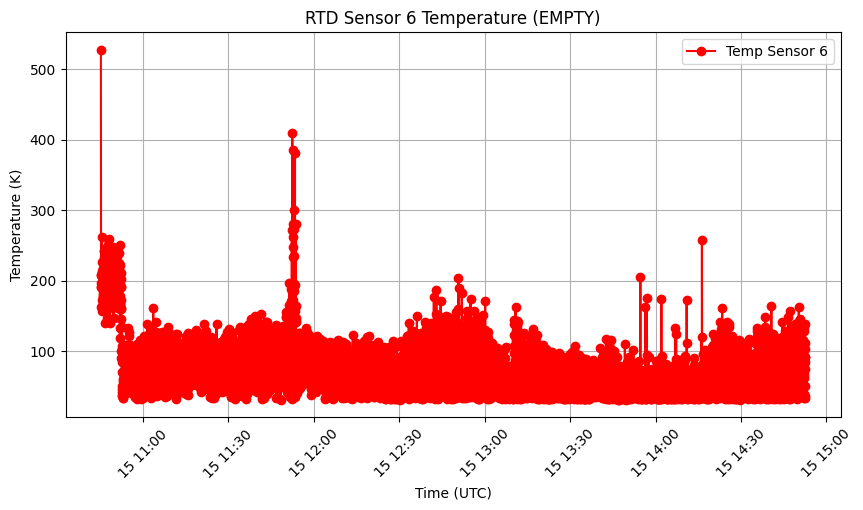

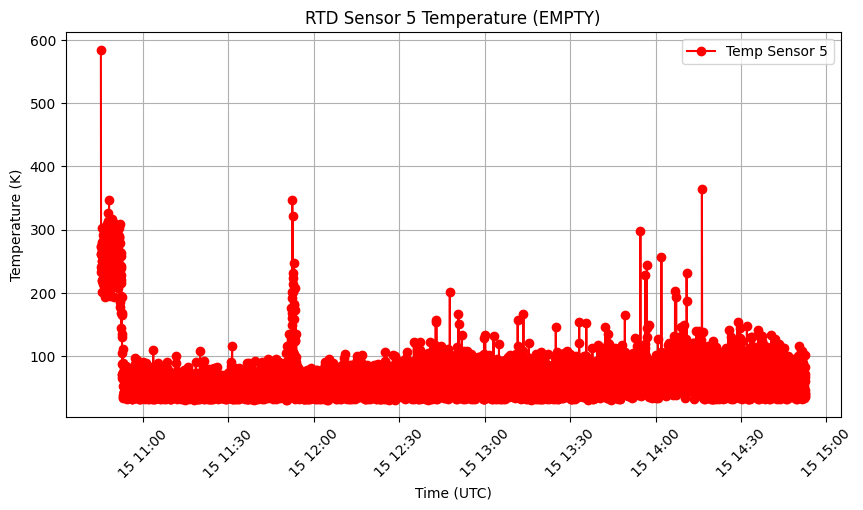

In [30]:
# 🔹 Graficar un sensor específico (ej. antepenúltimo sensor)
sensor_id = 5  # índice del antepenúltimo sensor
plt.figure(figsize=(10, 5))
plt.plot(timestamps, temp[:, sensor_id], marker='o', linestyle='-', color='r', label=f'Temp Sensor {sensor_id+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title(f"RTD Sensor {sensor_id+1} Temperature (EMPTY)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 🔹 Graficar un sensor específico (ej.)
sensor_id = 4  # índice 
plt.figure(figsize=(10, 5))
plt.plot(timestamps, temp[:, sensor_id], marker='o', linestyle='-', color='r', label=f'Temp Sensor {sensor_id+1}')
plt.xlabel("Time (UTC)")
plt.ylabel("Temperature (K)")
plt.title(f"RTD Sensor {sensor_id+1} Temperature (EMPTY)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

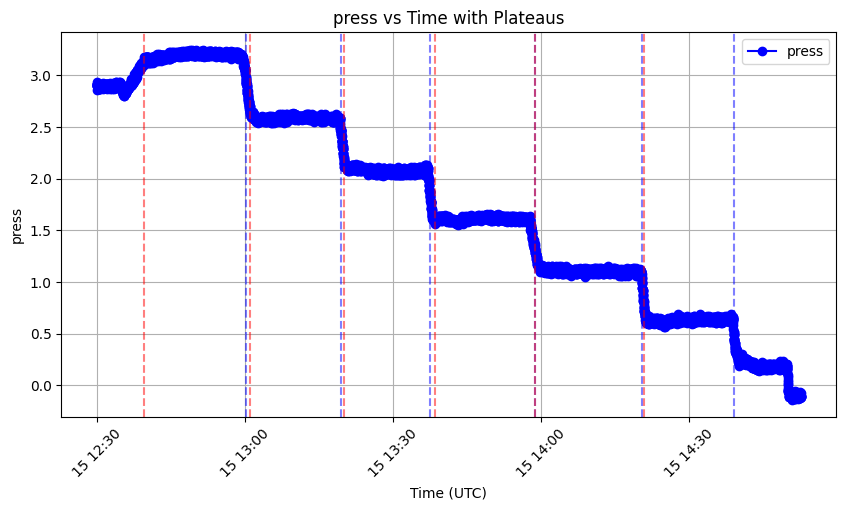

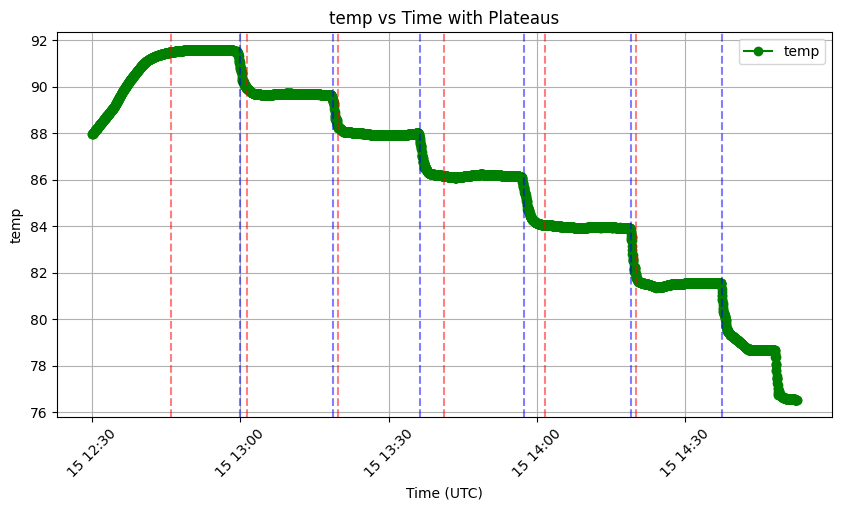

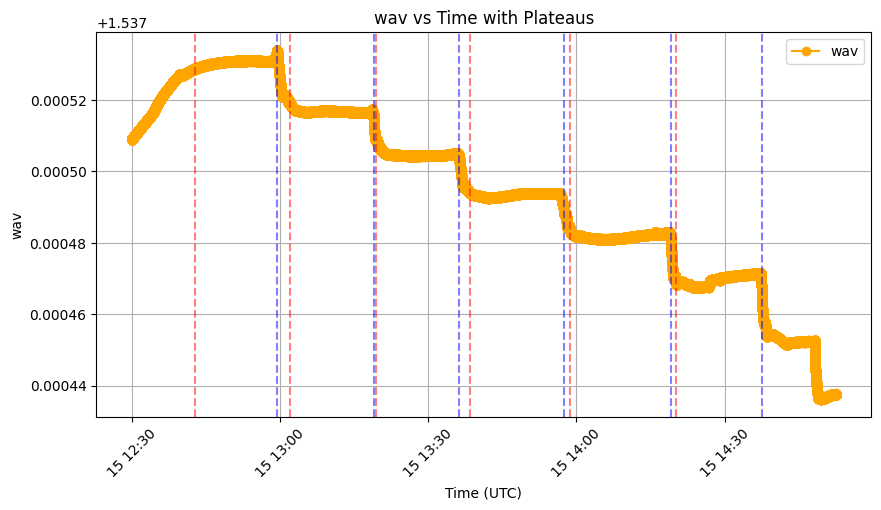


Plateaus comunes entre press, temp y wav:
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:26.612831
1: 2025-05-15 13:02:08.268865 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:12.709316
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:19:04
5: 2025-05-15 14:20:10 → 2025-05-15 14:20:27
6: 2025-05-15 14:20:54 → 2025-05-15 14:37:24


In [31]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

def find_plateaus(values, times, tolerance=0.01, min_plateau_length=500):
    """
    Encuentra plateaus en los datos.
    - values: array de valores.
    - times: array de tiempos en segundos.
    - tolerance: diferencia máxima para considerar un plateau.
    - min_plateau_length: duración mínima del plateau en segundos.
    """
    plateaus = []
    start_idx = 0
    for i in range(1, len(values)):
        if abs(values[i] - values[start_idx]) > tolerance:
            duration = times[i - 1] - times[start_idx]
            if duration >= min_plateau_length:
                segment = values[start_idx:i]
                plateaus.append({
                    "t0": times[start_idx],
                    "tfin": times[i - 1],
                    "mean": np.mean(segment),
                    "std": np.std(segment),
                    "data": segment
                })
            start_idx = i
    return plateaus

def calculate_plateaus(input_filename, sensor_temp=0, sensor_wav=(0,0),
                       params=None, start_time=None):
    """
    Calcula plateaus para press, temp y wav a partir de un archivo ROOT.
    Permite filtrar los datos por un tiempo mínimo 'start_time'.
    """
    if params is None:
        params = {
            "press": {"tolerance": 0.01, "min_plateau_length": 500},
            "temp": {"tolerance": 0.01, "min_plateau_length": 500},
            "wav": {"tolerance": 0.01, "min_plateau_length": 500}
        }
    
    with uproot.open(input_filename) as file:
        peak_tree = file["peak"]
        press_tree = file["press"]
        temp_tree = file["temp"]
        
        peak_data = peak_tree.arrays(library="np")
        press_data = press_tree.arrays(library="np")
        temp_data = temp_tree.arrays(library="np")
    
    # --- Tiempos corregidos ---
    peak_times  = np.array([datetime.datetime.utcfromtimestamp(t) + datetime.timedelta(hours=2)
                            for t in peak_data["t"][:, 0]])  # primera polarización
    press_times = np.array([datetime.datetime.utcfromtimestamp(t) for t in press_data["t"]])
    temp_times  = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_data["t"]])
    
    # --- Filtrado temporal si se define start_time ---
    if start_time is not None:
        mask_peak  = peak_times >= start_time
        mask_press = press_times >= start_time
        mask_temp  = temp_times >= start_time
    else:
        mask_peak  = np.ones_like(peak_times, dtype=bool)
        mask_press = np.ones_like(press_times, dtype=bool)
        mask_temp  = np.ones_like(temp_times, dtype=bool)
    
    # --- Datos filtrados ---
    peak_times  = np.array([t.timestamp() for t in peak_times[mask_peak]])
    press_times = np.array([t.timestamp() for t in press_times[mask_press]])
    temp_times  = np.array([t.timestamp() for t in temp_times[mask_temp]])
    
    peak_values = peak_data["wav"][mask_peak, sensor_wav[0], sensor_wav[1]] * 1e6  # micro m
    press_values = press_data["press"][mask_press]
    temp_values  = temp_data["temp"][mask_temp, sensor_temp]
    
    # --- Buscar plateaus ---
    press_plateaus = find_plateaus(press_values, press_times, **params["press"])
    temp_plateaus  = find_plateaus(temp_values, temp_times, **params["temp"])
    wav_plateaus   = find_plateaus(peak_values, peak_times, **params["wav"])
    
    # --- Graficar ---
    for branch, times_arr, values_arr, plateaus, color in zip(
        ["press", "temp", "wav"],
        [press_times, temp_times, peak_times],
        [press_values, temp_values, peak_values],
        [press_plateaus, temp_plateaus, wav_plateaus],
        ["blue", "green", "orange"]):
        
        plt.figure(figsize=(10,5))
        plt.plot([datetime.datetime.fromtimestamp(t) for t in times_arr], values_arr, marker='o', linestyle='-', label=branch, color=color)
        for p in plateaus:
            plt.axvline(datetime.datetime.fromtimestamp(p["t0"]), color='red', linestyle='--', alpha=0.5)
            plt.axvline(datetime.datetime.fromtimestamp(p["tfin"]), color='blue', linestyle='--', alpha=0.5)
        plt.xlabel("Time (UTC)")
        plt.ylabel(branch)
        plt.title(f"{branch} vs Time with Plateaus")
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid()
        plt.show()
    
    # --- Plateaus comunes (intersección de intervalos) ---
    common_plateaus = []
    for p_press in press_plateaus:
        for p_temp in temp_plateaus:
            for p_wav in wav_plateaus:
                t_start = max(p_press["t0"], p_temp["t0"], p_wav["t0"])
                t_end   = min(p_press["tfin"], p_temp["tfin"], p_wav["tfin"])
                if t_end > t_start:
                    common_plateaus.append({"t0": t_start, "tfin": t_end})
    
    print("\nPlateaus comunes entre press, temp y wav:")
    for i, p in enumerate(common_plateaus):
        print(f"{i}: {datetime.datetime.fromtimestamp(p['t0'])} → {datetime.datetime.fromtimestamp(p['tfin'])}")
    
    return {"press": press_plateaus, "temp": temp_plateaus, "wav": wav_plateaus, "common": common_plateaus}

# --- Ejemplo de uso ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20250515.root"
start_time = datetime.datetime.strptime("2025-05-15 12:30:00", "%Y-%m-%d %H:%M:%S")

params = {
    "press": {"tolerance": 0.25, "min_plateau_length": 1000},
    "temp": {"tolerance": 0.5, "min_plateau_length": 800},
    "wav": {"tolerance": 5e-6, "min_plateau_length": 800}
}

plateaus_result = calculate_plateaus(input_filename, sensor_temp=7, sensor_wav=(1,0),
                                     params=params, start_time=start_time)


In [32]:
# Mostrar los plateaus comunes detectados
for i, p in enumerate(plateaus_result["common"]):
    print(f"{i}: {datetime.datetime.fromtimestamp(p['t0'])} → {datetime.datetime.fromtimestamp(p['tfin'])}")

# Añadir manualmente 2 plateaus extra
manual_plateaus = [
    {"t0": datetime.datetime(2025,5,15,14,40,0).timestamp(), "tfin": datetime.datetime(2025,5,15,14,45,0).timestamp()},
    {"t0": datetime.datetime(2025,5,15,14,50,0).timestamp(), "tfin": datetime.datetime(2025,5,15,14,54,0).timestamp()}
]

plateaus_result["common"].extend(manual_plateaus)

# Ordenar por tiempo de inicio
plateaus_result["common"] = sorted(plateaus_result["common"], key=lambda x: x["t0"])

# Verificar
print("\nLista final de plateaus (detectados + manuales):")
for i, p in enumerate(plateaus_result["common"]):
    print(f"{i}: {datetime.datetime.fromtimestamp(p['t0'])} → {datetime.datetime.fromtimestamp(p['tfin'])}")


0: 2025-05-15 12:45:52 → 2025-05-15 12:59:26.612831
1: 2025-05-15 13:02:08.268865 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:12.709316
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:19:04
5: 2025-05-15 14:20:10 → 2025-05-15 14:20:27
6: 2025-05-15 14:20:54 → 2025-05-15 14:37:24

Lista final de plateaus (detectados + manuales):
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:26.612831
1: 2025-05-15 13:02:08.268865 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:12.709316
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:19:04
5: 2025-05-15 14:20:10 → 2025-05-15 14:20:27
6: 2025-05-15 14:20:54 → 2025-05-15 14:37:24
7: 2025-05-15 14:40:00 → 2025-05-15 14:45:00
8: 2025-05-15 14:50:00 → 2025-05-15 14:54:00



=== Sensor FBG (0, 0) ===


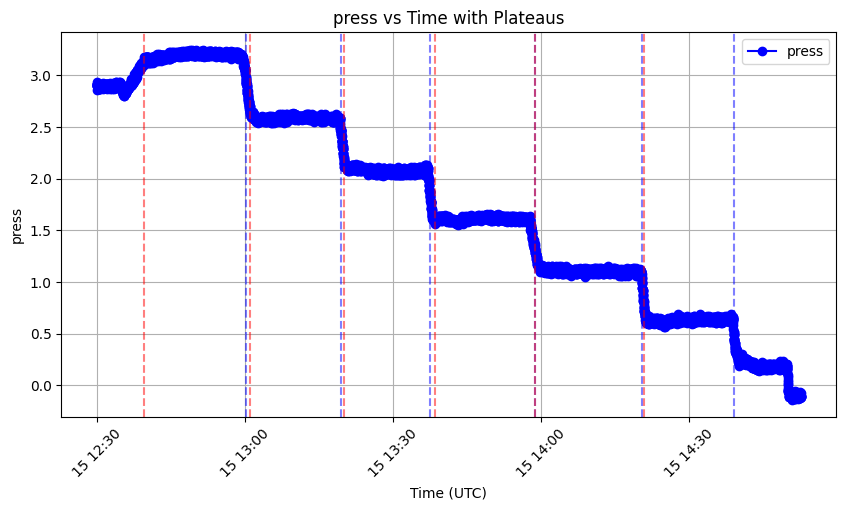

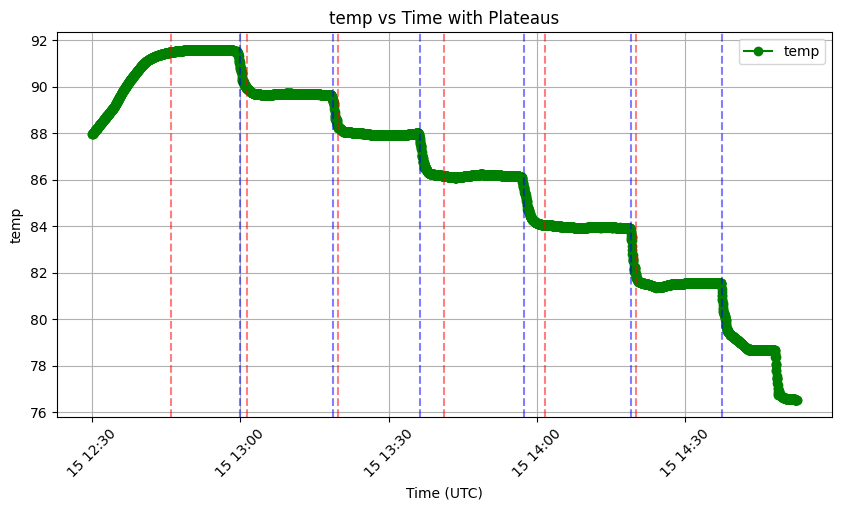

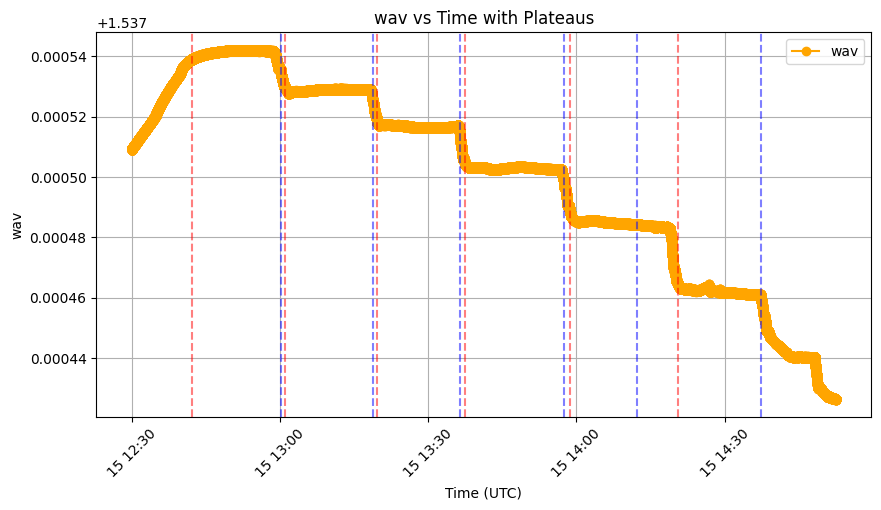


Plateaus comunes entre press, temp y wav:
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:50
1: 2025-05-15 13:01:19 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:16
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:12:16.141884
5: 2025-05-15 14:20:54 → 2025-05-15 14:37:24
Common plateaus (press, temp, wav):
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:50
1: 2025-05-15 13:01:19 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:16
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:12:16.141884
5: 2025-05-15 14:20:54 → 2025-05-15 14:37:24

=== Sensor FBG (0, 1) ===


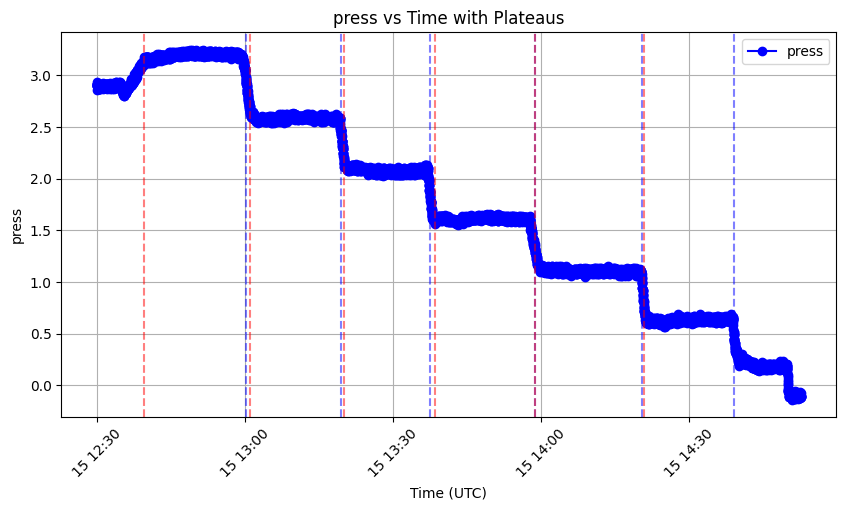

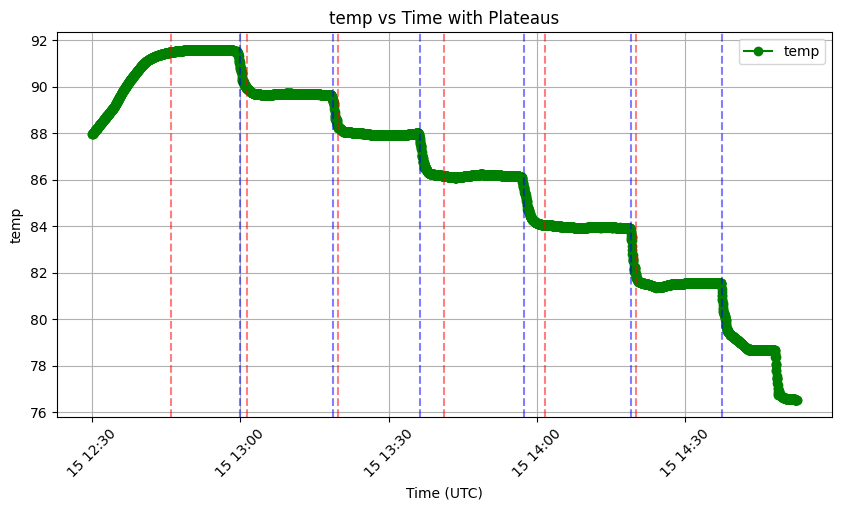

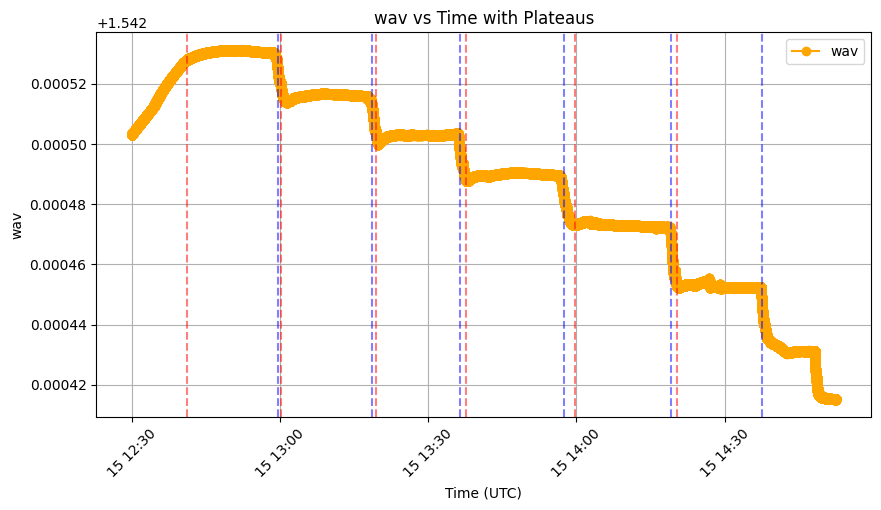


Plateaus comunes entre press, temp y wav:
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:40.028834
1: 2025-05-15 13:01:19 → 2025-05-15 13:18:33.813074
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:16
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:19:04
5: 2025-05-15 14:20:20.758030 → 2025-05-15 14:20:27
6: 2025-05-15 14:20:54 → 2025-05-15 14:37:24
Common plateaus (press, temp, wav):
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:40.028834
1: 2025-05-15 13:01:19 → 2025-05-15 13:18:33.813074
2: 2025-05-15 13:20:12 → 2025-05-15 13:36:16
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:01:41 → 2025-05-15 14:19:04
5: 2025-05-15 14:20:20.758030 → 2025-05-15 14:20:27
6: 2025-05-15 14:20:54 → 2025-05-15 14:37:24

=== Sensor FBG (1, 1) ===


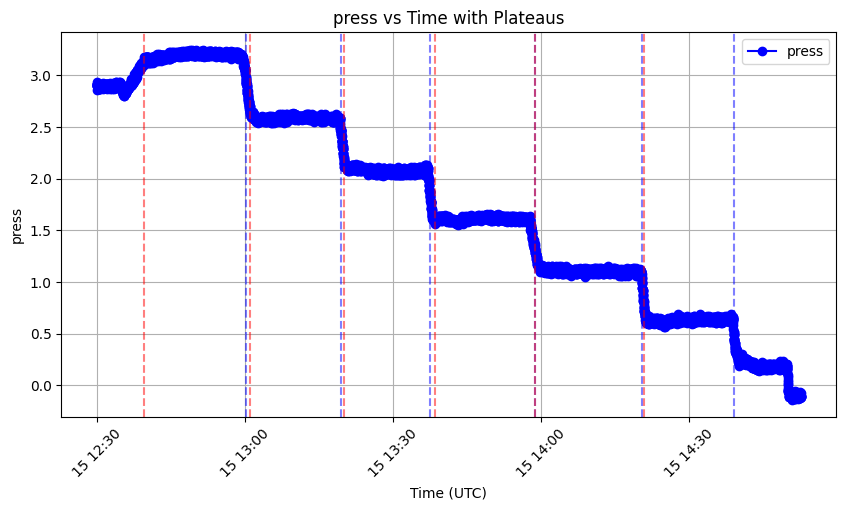

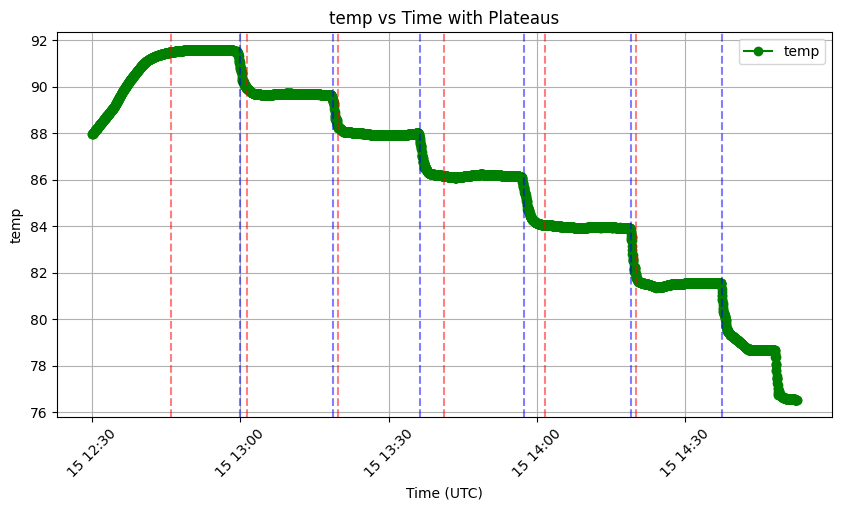

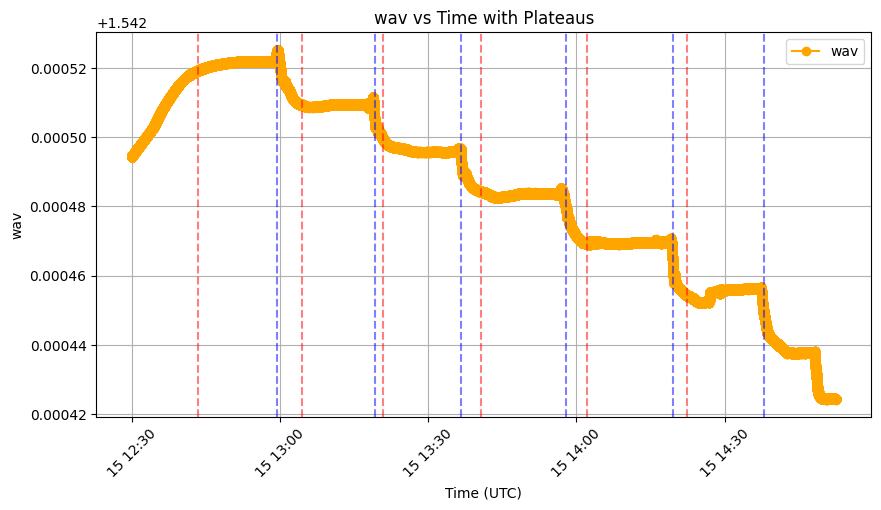


Plateaus comunes entre press, temp y wav:
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:21.548831
1: 2025-05-15 13:04:24.956893 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:53.565104 → 2025-05-15 13:36:16
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:02:10.949712 → 2025-05-15 14:19:04
5: 2025-05-15 14:22:20.798066 → 2025-05-15 14:37:24
Common plateaus (press, temp, wav):
0: 2025-05-15 12:45:52 → 2025-05-15 12:59:21.548831
1: 2025-05-15 13:04:24.956893 → 2025-05-15 13:18:42
2: 2025-05-15 13:20:53.565104 → 2025-05-15 13:36:16
3: 2025-05-15 13:41:07 → 2025-05-15 13:57:20
4: 2025-05-15 14:02:10.949712 → 2025-05-15 14:19:04
5: 2025-05-15 14:22:20.798066 → 2025-05-15 14:37:24

=== Sensor FBG (1, 4) ===


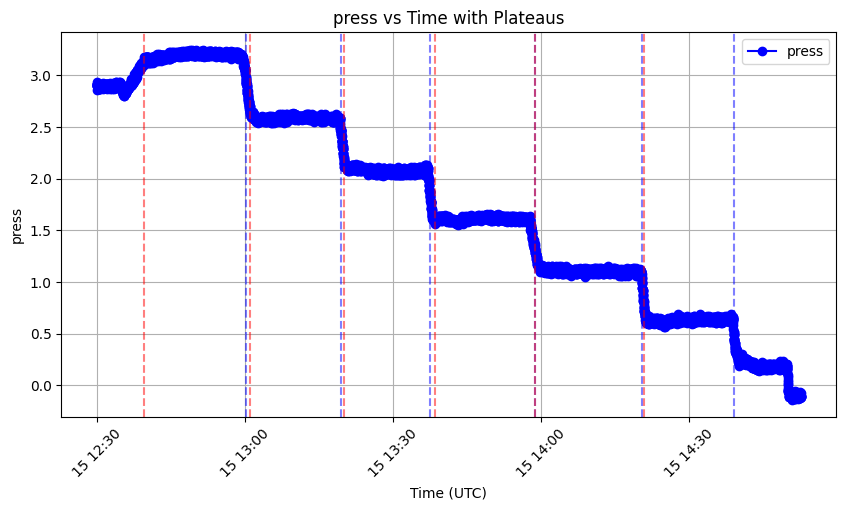

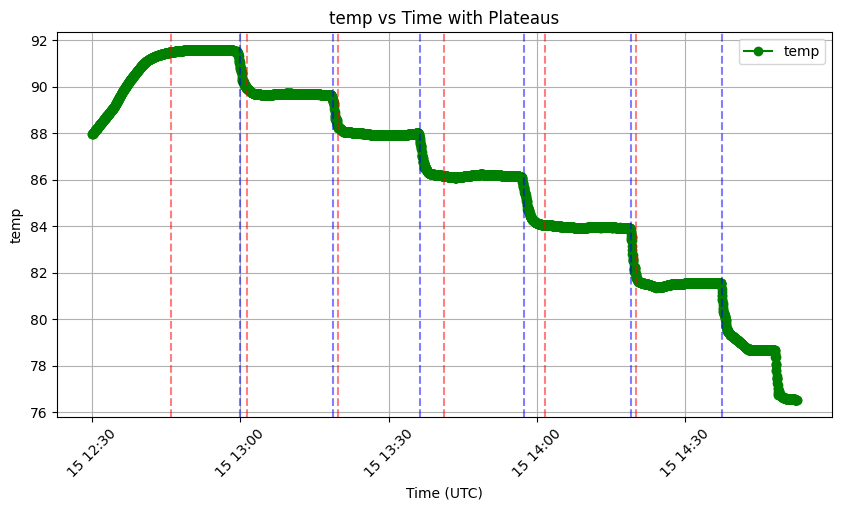

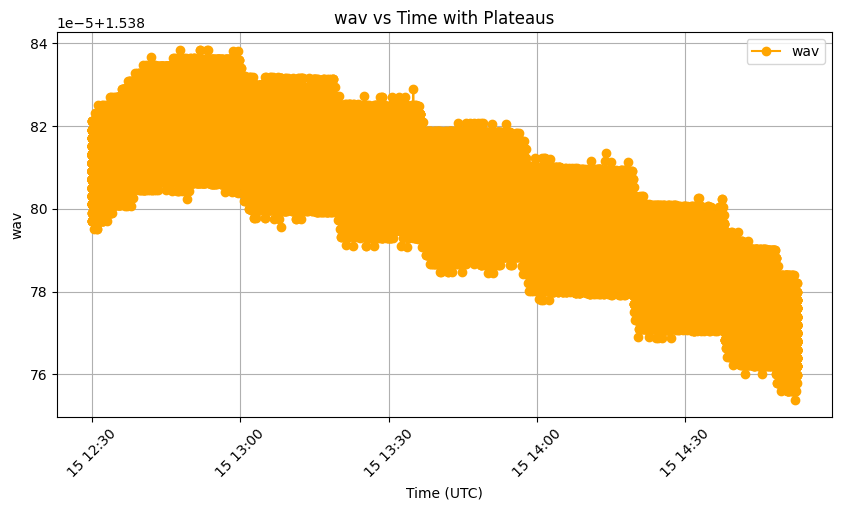


Plateaus comunes entre press, temp y wav:
No common plateaus found for this FBG.


In [34]:
# Lista de sensores FBG a analizar (tupla de índices: (i,j))
fbgs_to_check = [(0,0), (0,1), (1,1), (1,4)]  # añadir los que quieras

# Recorrer cada FBG y mostrar los plateaus comunes
for sensor_wav in fbgs_to_check:
    print(f"\n=== Sensor FBG {sensor_wav} ===")
    
    plateaus_result = calculate_plateaus(
        input_filename,
        sensor_temp=7,          # mismo sensor RTD que antes
        sensor_wav=sensor_wav,
        params=params,
        start_time=start_time
    )
    
    common = plateaus_result["common"]
    if len(common) == 0:
        print("No common plateaus found for this FBG.")
    else:
        print("Common plateaus (press, temp, wav):")
        for i, p in enumerate(common):
            t0 = datetime.datetime.fromtimestamp(p["t0"])
            tfin = datetime.datetime.fromtimestamp(p["tfin"])
            print(f"{i}: {t0} → {tfin}")
